In [1]:
import os
import time
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
import MGLensing
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy import integrate
from copy import deepcopy


# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing


In [2]:
# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

# Survey
LSST Y1 setup

In [ ]:
MGL = MGLensing.MGL("config_ccl_comparison.yaml")
zz = MGL.Survey.zz_integr
nbin = MGL.Survey.nbin_s


l_wl_max, l_gc_max = MGL.Survey.ells_wl_max, MGL.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL.Survey.l_wl, MGL.Survey.l_gc, MGL.Survey.l_xc

Source galaxy distribution for bin  0  integrates to  0.9999201944616665
Lens galaxy distribution for bin  0  integrates to  1.0000005679267678
Source galaxy distribution for bin  1  integrates to  1.000000581682923
Lens galaxy distribution for bin  1  integrates to  1.0000007725408466
Source galaxy distribution for bin  2  integrates to  1.0000005285358693
Lens galaxy distribution for bin  2  integrates to  1.000000501287934
Source galaxy distribution for bin  3  integrates to  0.9999996535305957
Lens galaxy distribution for bin  3  integrates to  0.9999997816368513
Source galaxy distribution for bin  4  integrates to  0.9872862583339359
Lens galaxy distribution for bin  4  integrates to  1.0000000029598894
model["nl_model"] =  0
initialising hmcode


Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  240
gc_masked_ells:  178
xc_masked_ells:  295
3x2pt_masked_ells:  713
computing data covariance


cov_flat:  (1100, 1100)
cov_flat_masked:  (713, 713)
managed to do cholesky decomposition
######CHOLESKY!!!!########
finish computing mock data
################################
model["nl_model"] =  0
initialising hmcode
Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
################################
checking parameters for theory....
all good with the model parameters
################################


# Cosmologies
HMcode2020 for LCDM nonlinear, no neutrinos

In [4]:
params = {
    'Omega_m' :  0.315,
    'Omega_c' :  0.315-0.05,
    'Omega_cb' :  0.315,
    'Omega_nu':  0.,
    'As'      :  np.exp(3.07)*1.e-10,
    'Omega_b' :  0.05,
    'ns'      :  0.96,
    'h'       :  0.67,
    'Mnu'     :  0.0,
    'w0'      :  -1.0,
    'wa'      :  0.0,
    'a1_IA': 0.16,
    'eta1_IA': 1.66,
    'beta_IA': 0.,
    # modified gravity parameters

    # time-dependent growth index
    'gamma0': 0.47,
    'gamma1': -0.19,
    'q1_gamma': 0.7,
    # nDGP with Omega_rc = 0.25
    'log10Omega_rc': np.log10(0.25),
    # mu and Sigma
    'mu0': 0.7,
    'sigma0': 0.,
    'q1': 1.,
    # Hu-Sawicki f(R)
    'log10f_R0': -5.0,
}

b0 = 0.68
bias1_arr = np.array([b0*(1.+z_bin_center_i) for z_bin_center_i in MGL.Survey.z_bin_center_l ])
for bin_i in range(nbin):
    params[f'b1_{bin_i+1}']=bias1_arr[bin_i]

In [5]:
# first call MGL
NL_MODEL_HMCODE = 0
NL_MODEL_BACCO = 1
NL_MODEL_NDGP = 2
NL_MODEL_GAMMAZ = 3
NL_MODEL_MUSIGMA = 4
NL_MODEL_DS = 5
NL_MODEL_FOFR = 6


models = {
    'GR_nonlin': {'nl_model': NL_MODEL_HMCODE, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'GR_lin': {'nl_model': NL_MODEL_HMCODE, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},

    'nDGP_nonlin': {'nl_model': NL_MODEL_NDGP, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'nDGP_lin': {'nl_model': NL_MODEL_NDGP, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},

    'gammaz_nonlin': {'nl_model': NL_MODEL_GAMMAZ, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'gammaz_lin': {'nl_model': NL_MODEL_GAMMAZ, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    
    'muSigma_nonlin': {'nl_model': NL_MODEL_MUSIGMA, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'muSigma_lin': {'nl_model': NL_MODEL_MUSIGMA, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},

    'fofR_nonlin': {'nl_model': NL_MODEL_FOFR, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'fofR_lin': {'nl_model': NL_MODEL_FOFR, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    }

# Power spectrum comparison

In [6]:
power_spectra = {}
for model_opt in models:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
            'pgm': pgm,
            'pgg': pgg
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  0
initialising hmcode
Model: GR_nonlin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  0
initialising hmcode


Model: GR_lin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  2
initialising nDGP ReACT
Model: nDGP_nonlin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  2


initialising nDGP ReACT
Model: nDGP_lin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  3
initialising Growth Index Parametrisation


Model: gammaz_nonlin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  3
initialising Growth Index Parametrisation


Model: gammaz_lin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  4
initialising mu-Sigma
Model: muSigma_nonlin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  4
initialising mu-Sigma


Model: muSigma_lin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode


Model: fofR_nonlin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode


Model: fofR_lin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)


In [19]:
_, rcom = MGL.get_expansion_and_rcom(params)
# pick 3 redshifts
z_int_pick = [40, 100, 120] #goes from 0 to 255
def k2ell(x, ind=z_int_pick[0]):
    return x*rcom[ind]-0.5
def ell2k(x, ind=z_int_pick[0]):
    return (x+0.5)/rcom[ind]
def k2ell1(x, ind=z_int_pick[1]):
    return x*rcom[ind]-0.5
def ell2k1(x, ind=z_int_pick[1]):
    return (x+0.5)/rcom[ind]
def k2ell2(x, ind=z_int_pick[2]):
    return x*rcom[ind]-0.5
def ell2k2(x, ind=z_int_pick[2]):
    return (x+0.5)/rcom[ind]
f_arr = [k2ell, k2ell1, k2ell2]
f_inv_arr = [ell2k, ell2k1, ell2k2]
# pick the bins
bin_i=2
bin_j=3

In [20]:
colors = sns.color_palette("Paired")
model_opt_nonlin = ['GR_nonlin', 'nDGP_nonlin', 'muSigma_nonlin', 'fofR_nonlin', 'gammaz_nonlin']
model_opt_lin = ['GR_lin', 'nDGP_lin', 'muSigma_lin', 'fofR_lin', 'gammaz_lin']
labels = ['GR', 'nDGP', '$\\mu-\\Sigma$', '$f(R)$', '$\\gamma(z)$']

  ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='lower left', frameon=False, title_fontsize=20)



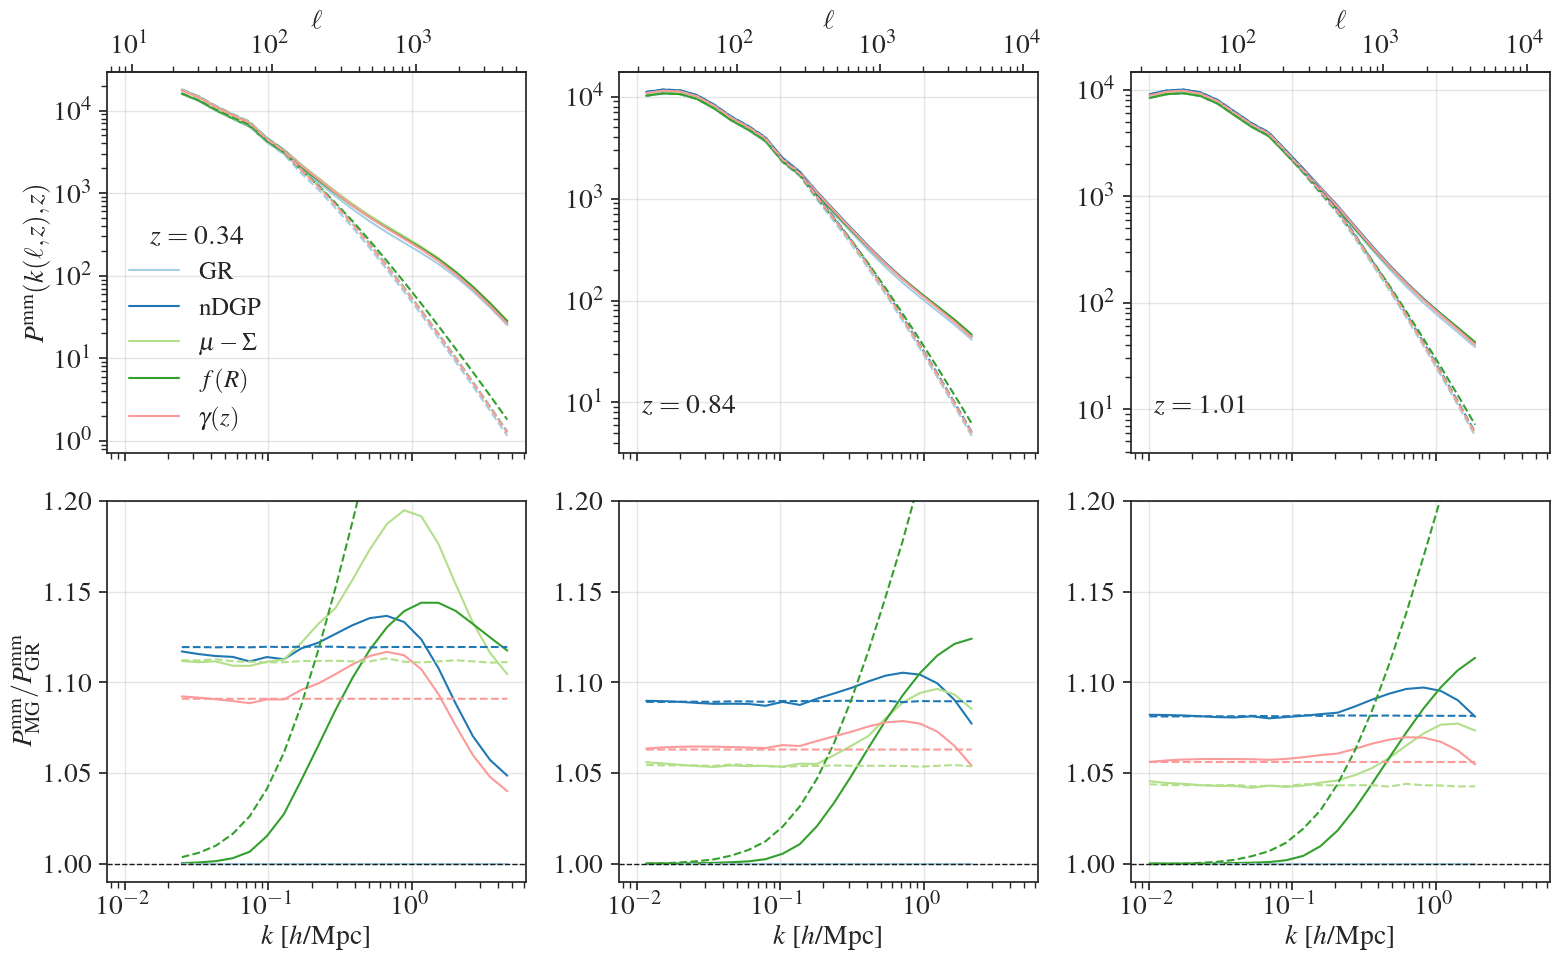

In [21]:
fig, ax = plt.subplots(2, 3, figsize=(16, 10), facecolor='w', gridspec_kw={'height_ratios':[1,1] }, sharex=True)
pmm_gr_nl = power_spectra['GR_nonlin']['pmm']
pmm_gr_lin = power_spectra['GR_lin']['pmm']
for i in range(3):
    for j, model_opt in enumerate(model_opt_nonlin):
        k_ell = power_spectra[model_opt]['k']
        pmm = power_spectra[model_opt]['pmm']
        ax[0][i].loglog(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]], linewidth=1.5, color = colors[j], label=labels[j] if i == 0 else '')
        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_gr_nl[:, z_int_pick[i]], linewidth=1.5, color = colors[j])
    for j, model_opt in enumerate(model_opt_lin):
        k_ell = power_spectra[model_opt]['k']
        pmm = power_spectra[model_opt]['pmm']
        ax[0][i].loglog(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]], linewidth=1.5, color = colors[j], linestyle='--')
        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[j], linestyle='--')
    ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='lower left', frameon=False, title_fontsize=20)
    ax[1][i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[0][i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[0][i].grid(alpha=0.5)
    ax[1][i].grid(alpha=0.5)
    ax[1][i].set_ylim(0.99, 1.2)    
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0][0].set_ylabel("$P^{\\rm mm}(k(\ell, z), z)$")
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm MG}/P_{\\rm GR}^{\\rm mm}$")
plt.tight_layout()

# Angular power spectrum: Shear

In [22]:
ang_power_spectra = {}
for model_opt in models:
    try:
        cl_ll_mgl, cl_gg_mgl, cl_lg_mgl, cl_gl_mgl =  MGL.get_c_ells(params, models[model_opt])
        print(f"Model: {model_opt}, cl_ll_mgl shape: {cl_ll_mgl.shape}, cl_gg_mgl shape: {cl_gg_mgl.shape}, cl_lg_mgl shape: {cl_lg_mgl.shape}, cl_gl_mgl shape: {cl_gl_mgl.shape}")
        ang_power_spectra[model_opt] = {
            'wl': cl_ll_mgl,
            'gc': cl_gg_mgl,
            'xc': cl_gl_mgl
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  0
initialising hmcode
Theo model:  {'nl_model': 0, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: GR_nonlin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  0
initialising hmcode


Theo model:  {'nl_model': 0, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: GR_lin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  2
initialising nDGP ReACT
Theo model:  {'nl_model': 2, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


Model: nDGP_nonlin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  2
initialising nDGP ReACT
Theo model:  {'nl_model': 2, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: nDGP_lin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  3


initialising Growth Index Parametrisation
Theo model:  {'nl_model': 3, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: gammaz_nonlin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  3


initialising Growth Index Parametrisation
Theo model:  {'nl_model': 3, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


Model: gammaz_lin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  4
initialising mu-Sigma
Theo model:  {'nl_model': 4, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: muSigma_nonlin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: muSigma_lin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode


Theo model:  {'nl_model': 6, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


Model: fofR_nonlin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode


Theo model:  {'nl_model': 6, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: fofR_lin, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)


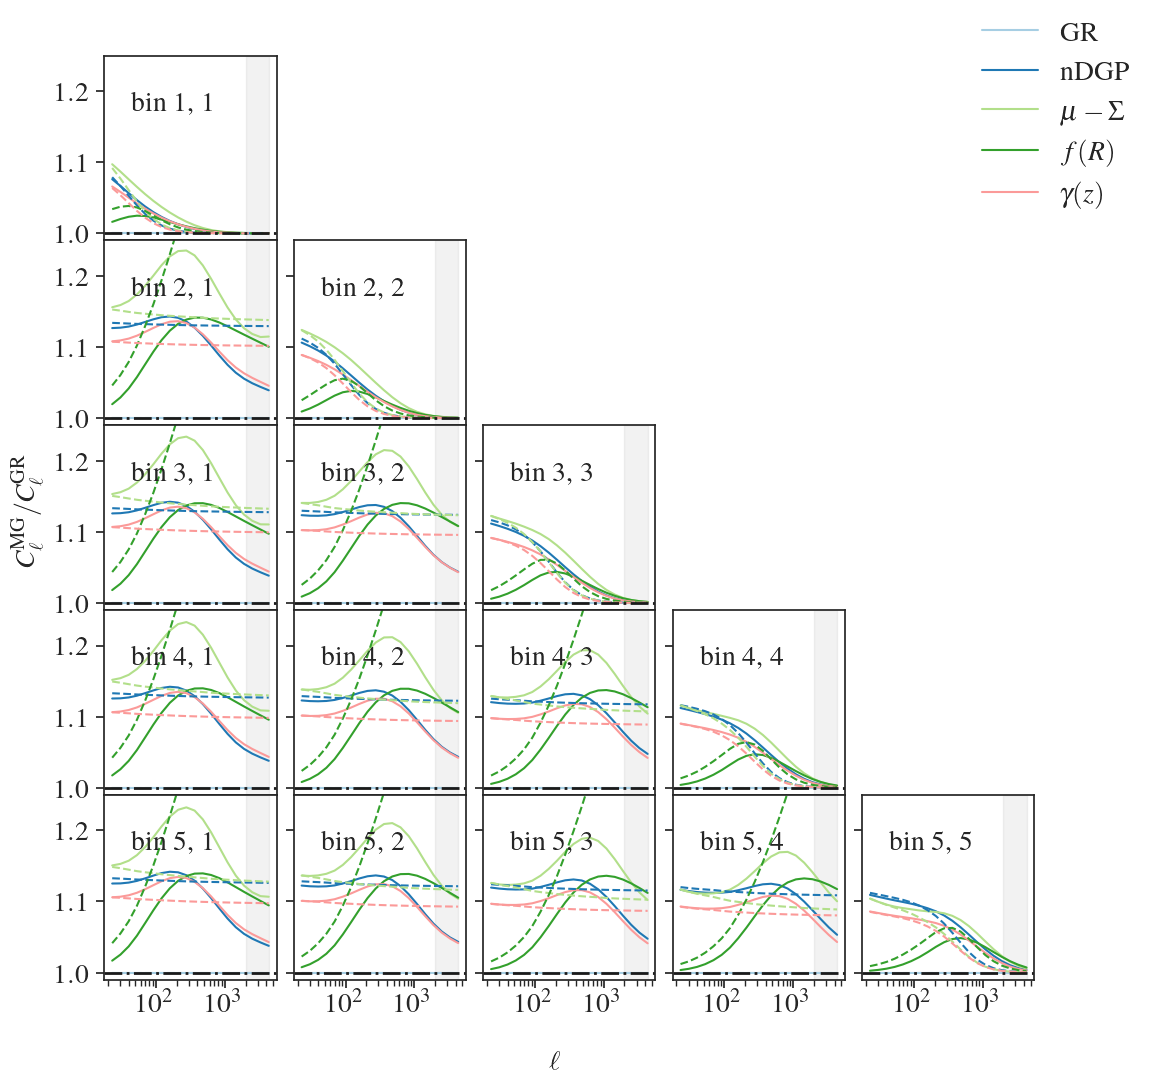

In [23]:
cell_gr_nl = ang_power_spectra['GR_nonlin']['wl']
cell_gr_lin = ang_power_spectra['GR_lin']['wl']

fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            for l, model_opt in enumerate(model_opt_nonlin):
                cl_ll_mgl = ang_power_spectra[model_opt]['wl']
                ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cell_gr_nl[:, i, j], linewidth=1.5, color = colors[l])
            for l, model_opt in enumerate(model_opt_lin):
                cl_ll_mgl = ang_power_spectra[model_opt]['wl']
                ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cell_gr_lin[:, i, j], linewidth=1.5, color = colors[l], linestyle='--')
            ax[i, j].set_ylim(0.99, 1.25)
            ax[i,j].text(.4, .7, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) 
            ax[i, j].axhline(y=1, linestyle='-.', linewidth=2, color='k')
            ax[i, j].axvspan(xmin=l_wl_max[i, j], xmax=l_wl[-1], color='grey', alpha=0.1)
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm MG}_\ell/C^{\rm GR}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)

# Non-zero $\Sigma_0$

In [12]:
cls_list = []
vary_sigma0 = np.linspace(-0.5, 0.5, 5)
labels_sigma = ['$\\Sigma_0 = $'+str(round(vary_sigma0_i, 2)) for vary_sigma0_i in vary_sigma0]
for sigma0_i in vary_sigma0:
    params_new = params.copy()
    params_new['sigma0'] = sigma0_i
    print(f"Calculating cls for sigma0 = {sigma0_i}")
    cls_list.append(MGL.get_c_ells(params_new, models['muSigma_nonlin'])[0])

Calculating cls for sigma0 = -0.5
model["nl_model"] =  4
initialising mu-Sigma
Theo model:  {'nl_model': 4, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Calculating cls for sigma0 = -0.25
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Calculating cls for sigma0 = 0.0
model["nl_model"] =  4
initialising mu-Sigma
Theo model:  {'nl_model': 4, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


Calculating cls for sigma0 = 0.25
model["nl_model"] =  4
initialising mu-Sigma
Theo model:  {'nl_model': 4, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Calculating cls for sigma0 = 0.5
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


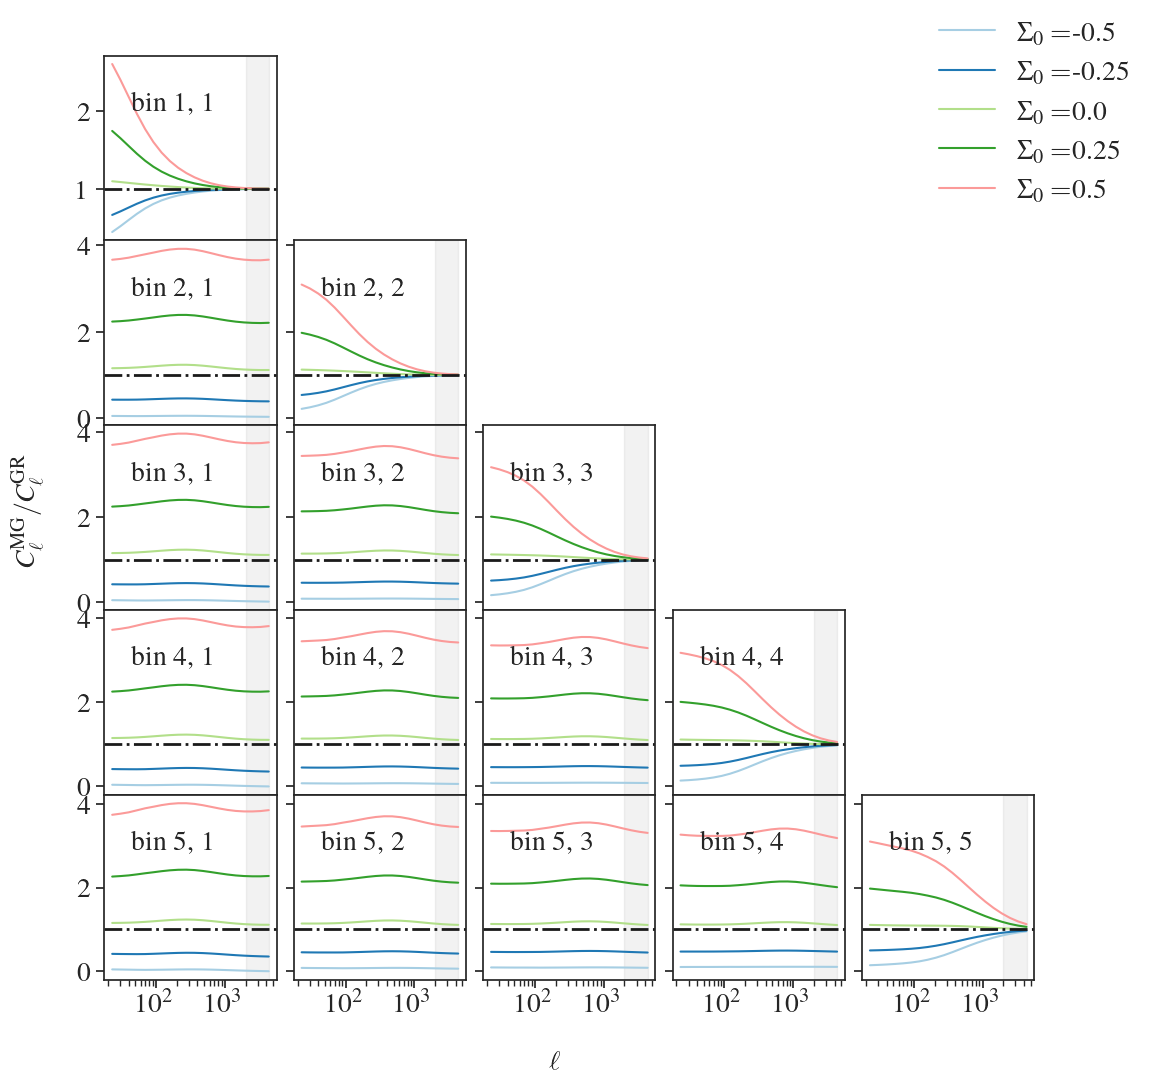

In [13]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            for l in range(len(cls_list)):
                cl_ll_mgl = cls_list[l]
                ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cell_gr_nl[:, i, j], linewidth=1.5, color = colors[l])
            #ax[i, j].set_ylim(0.99, 1.25)
            ax[i,j].text(.4, .7, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) 
            ax[i, j].axhline(y=1, linestyle='-.', linewidth=2, color='k')
            ax[i, j].axvspan(xmin=l_wl_max[i, j], xmax=l_wl[-1], color='grey', alpha=0.1)
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm MG}_\ell/C^{\rm GR}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels_sigma, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)

# Pseudo power spectra 
See definition in https://arxiv.org/abs/1812.05594 

In [27]:
models_pseudo = {
    'nDGP_pseudo': {'nl_model': NL_MODEL_NDGP, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},

    'gammaz_pseudo': {'nl_model': NL_MODEL_GAMMAZ, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    
    'muSigma_pseudo': {'nl_model': NL_MODEL_MUSIGMA, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},

    'fofR_pseudo': {'nl_model': NL_MODEL_FOFR, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    

    }
model_opt_pseudo = ['nDGP_pseudo', 'muSigma_pseudo', 'gammaz_pseudo', 'fofR_pseudo']
model_opt_nonlin = ['nDGP_nonlin', 'muSigma_nonlin', 'gammaz_nonlin', 'fofR_nonlin']
labels = ['nDGP', '$\\mu-\\Sigma$', '$\\gamma(z)$', '$f(R)$']

In [28]:
for model_opt in models_pseudo:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models_pseudo[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
            'pgm': pgm,
            'pgg': pgg
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  2
initialising nDGP ReACT
Model: nDGP_pseudo, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  3
initialising Growth Index Parametrisation


Model: gammaz_pseudo, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  4
initialising mu-Sigma
Model: muSigma_pseudo, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  6


initialising f(R) ReACT
initialising hmcode
Model: fofR_pseudo, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)


  ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='lower left', frameon=False, title_fontsize=20)



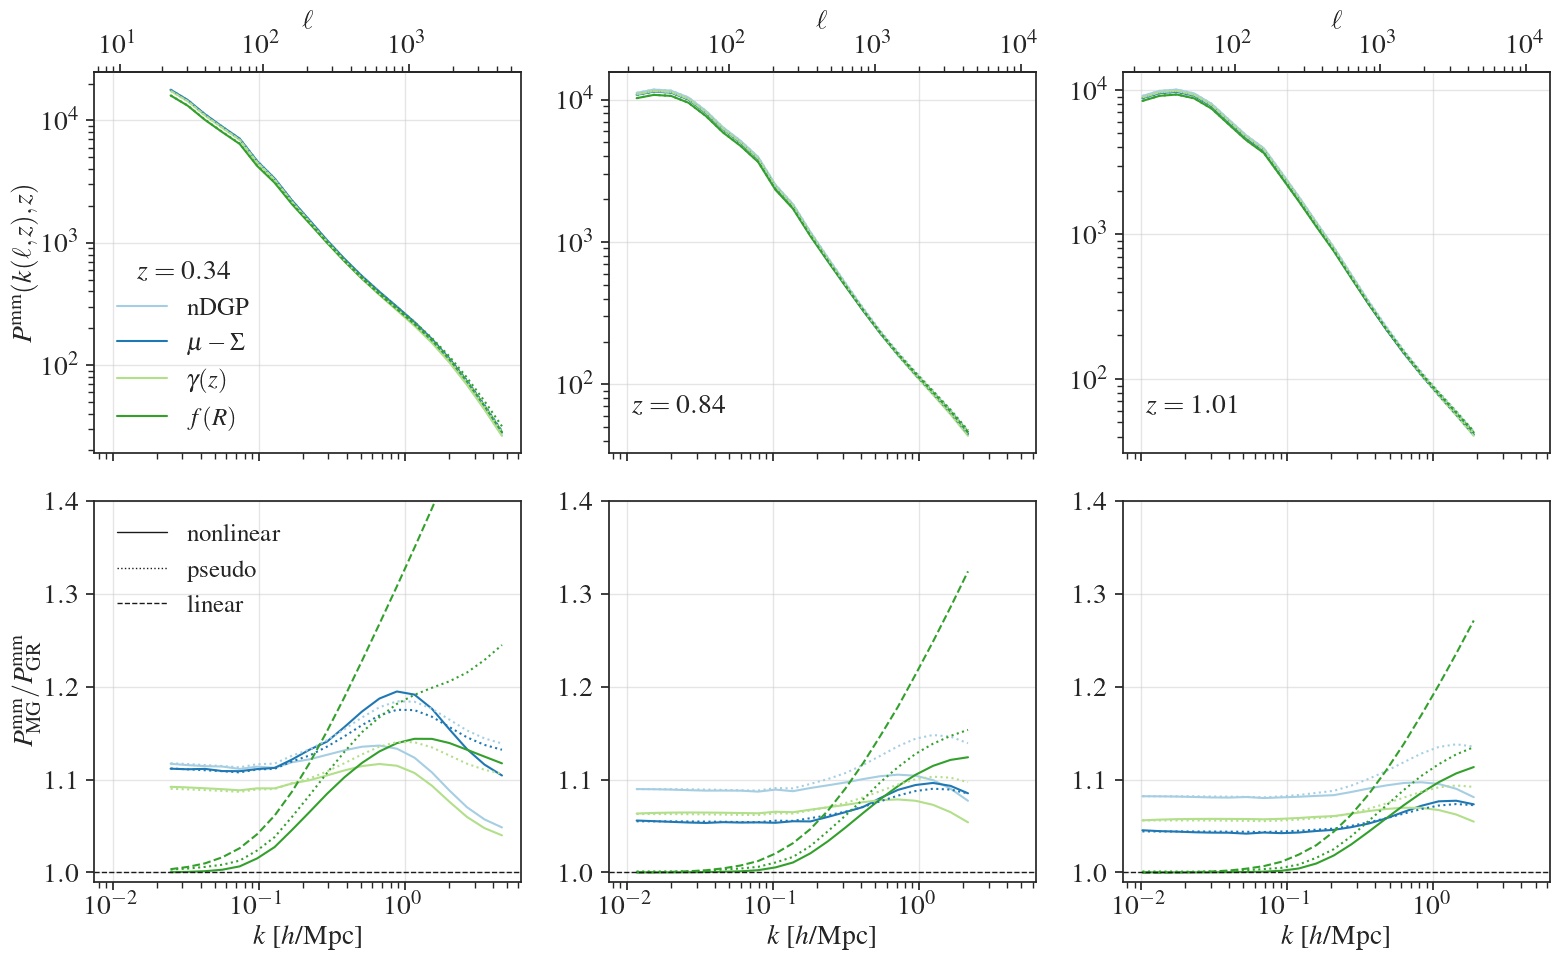

In [29]:
fig, ax = plt.subplots(2, 3, figsize=(16, 10), facecolor='w', gridspec_kw={'height_ratios':[1,1] }, sharex=True)
pmm_gr_nl = power_spectra['GR_nonlin']['pmm']
pmm_gr_lin = power_spectra['GR_lin']['pmm']
pmm_fofr_lin = power_spectra['fofR_lin']['pmm']
for i in range(3):
    for j, model_opt in enumerate(model_opt_nonlin):
        k_ell = power_spectra[model_opt]['k']
        pmm = power_spectra[model_opt]['pmm']
        ax[0][i].loglog(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]], linewidth=1.5, color = colors[j], label=labels[j] if i == 0 else '')
        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_gr_nl[:, z_int_pick[i]], linewidth=1.5, color = colors[j])
    for j, model_opt in enumerate(model_opt_pseudo):
        k_ell = power_spectra[model_opt]['k']
        pmm = power_spectra[model_opt]['pmm']
        ax[0][i].loglog(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]], linewidth=1.5, color = colors[j], linestyle=':')
        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_gr_nl[:, z_int_pick[i]], linewidth=1.5, color = colors[j], linestyle=':')
     
    ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm_fofr_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[j], linestyle='--')    
    ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='lower left', frameon=False, title_fontsize=20)
    ax[1][i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[0][i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[0][i].grid(alpha=0.5)
    ax[1][i].grid(alpha=0.5)
    ax[1][i].set_ylim(0.99, 1.4)    
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[1][0].axhline(y=0., color='k', linestyle='-', linewidth=1, label='nonlinear')
ax[1][0].axhline(y=0., color='k', linestyle=':', linewidth=1, label='pseudo')
ax[1][0].axhline(y=0., color='k', linestyle='--', linewidth=1, label='linear')
ax[1][0].legend(loc='upper left', frameon=False, fontsize=18)
ax[0][0].set_ylabel("$P^{\\rm mm}(k(\ell, z), z)$")
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm MG}/P_{\\rm GR}^{\\rm mm}$")
plt.tight_layout()

In [30]:
for model_opt in models_pseudo:
    try:
        cl_ll_mgl, cl_gg_mgl, cl_lg_mgl, cl_gl_mgl =  MGL.get_c_ells(params, models_pseudo[model_opt])
        print(f"Model: {model_opt}, cl_ll_mgl shape: {cl_ll_mgl.shape}, cl_gg_mgl shape: {cl_gg_mgl.shape}, cl_lg_mgl shape: {cl_lg_mgl.shape}, cl_gl_mgl shape: {cl_gl_mgl.shape}")
        ang_power_spectra[model_opt] = {
            'wl': cl_ll_mgl,
            'gc': cl_gg_mgl,
            'xc': cl_gl_mgl
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")



model["nl_model"] =  2
initialising nDGP ReACT
Theo model:  {'nl_model': 2, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: nDGP_pseudo, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  3
initialising Growth Index Parametrisation


Theo model:  {'nl_model': 3, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: gammaz_pseudo, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: muSigma_pseudo, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode


Theo model:  {'nl_model': 6, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: fofR_pseudo, cl_ll_mgl shape: (20, 5, 5), cl_gg_mgl shape: (20, 5, 5), cl_lg_mgl shape: (20, 5, 5), cl_gl_mgl shape: (20, 5, 5)


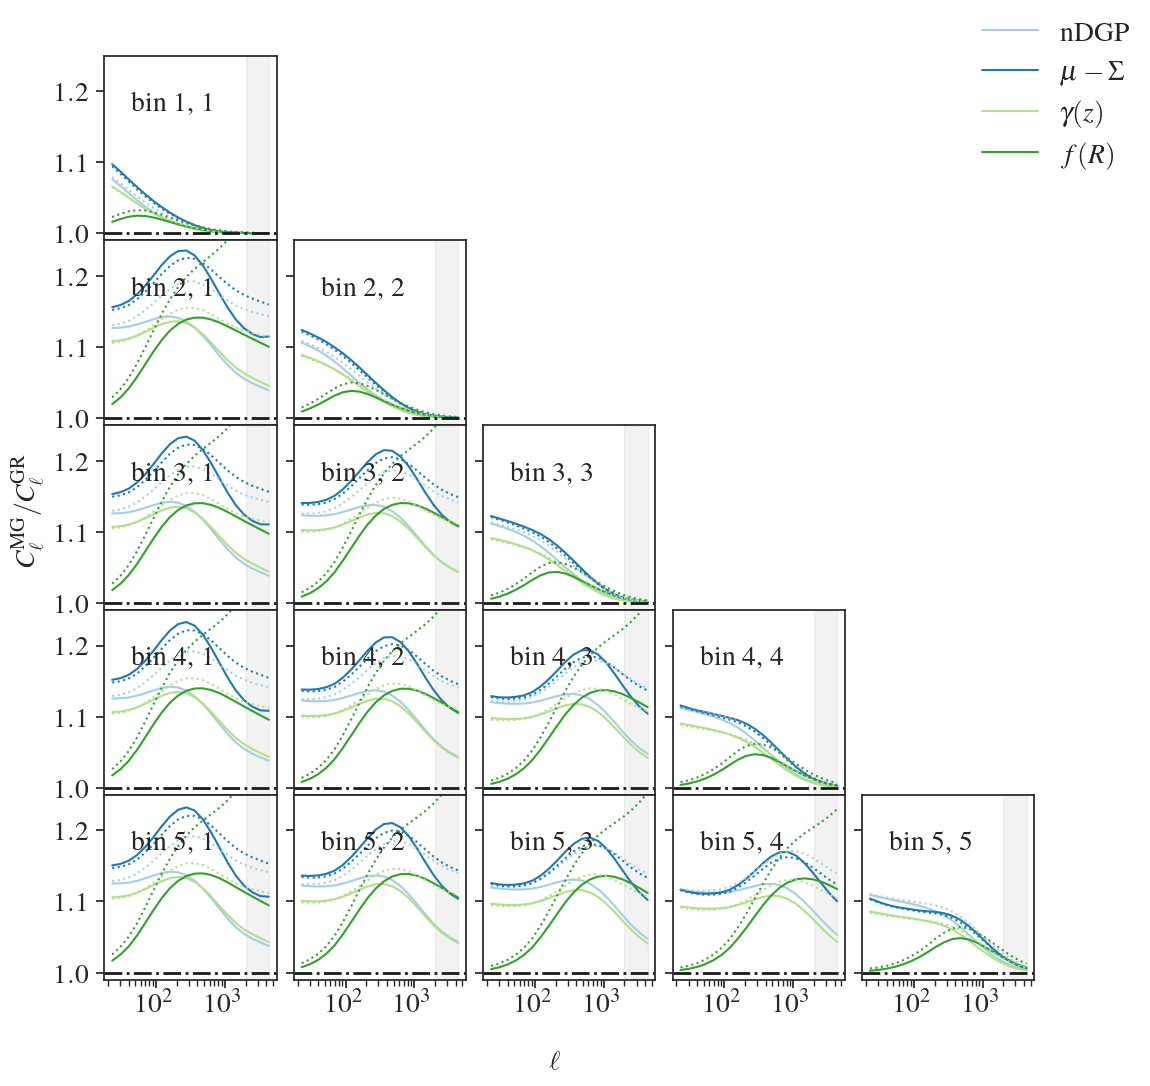

In [31]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            for l, model_opt in enumerate(model_opt_nonlin):
                cl_ll_mgl = ang_power_spectra[model_opt]['wl']
                ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cell_gr_nl[:, i, j], linewidth=1.5, color = colors[l])
            for l, model_opt in enumerate(model_opt_pseudo):
                cl_ll_mgl = ang_power_spectra[model_opt]['wl']
                ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cell_gr_nl[:, i, j], linewidth=1.5, color = colors[l], linestyle=':')
            ax[i, j].set_ylim(0.99, 1.25)
            ax[i,j].text(.4, .7, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) 
            ax[i, j].axhline(y=1, linestyle='-.', linewidth=2, color='k')
            ax[i, j].axvspan(xmin=l_wl_max[i, j], xmax=l_wl[-1], color='grey', alpha=0.1)
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm MG}_\ell/C^{\rm GR}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)